In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pysentiment2 as ps

In [14]:
df = pd.read_csv("./eagles_sentiment_2025_26_corrected_new.csv")

In [15]:
sentiment_filters = {
    # overall player quality / public perception
    "status": (
        "MVP OR mvp OR star OR superstar OR special OR legend OR elite OR generational OR icon OR "
        "franchise QB OR franchise player OR top tier OR top-5 OR top 5 OR best in the league OR "
        "future star OR future of the franchise OR breakout star OR rising star OR "
        "fraud OR overrated OR underrated OR bust OR trash OR washed OR cooked OR "
        "liability OR overpaid OR waste of money OR not worth the contract"
    ),
    # in-game pressure, performance in key moments, narrative language
    "clutch_anxiety": (
        "clutch OR choked OR choke OR sold OR sold the game OR threw the game OR "
        "ice in his veins OR game on the line OR when it mattered OR big moment OR "
        "came up short OR disappeared OR folded OR no show OR quiet night OR "
        "showed up OR stepped up OR carried the team"
    ),
    # tactical / decision making / execution
    "tactical": (
        "bad read OR missed read OR missed the read OR checkdown OR check down OR "
        "forced it OR forced the throw OR tunnel vision OR stared down OR "
        "progressions OR went through his reads OR pocket presence OR "
        "play call OR playcalling OR scheme OR schemed OR game plan OR "
        "adjustment OR adjustments OR coaching decision OR bad play call OR "
        "execution OR poor execution OR mental mistake OR football IQ"
    ),
    # physical condition, availability, effort, body-language
    "physicality": (
        "injured OR injury OR hurt OR banged up OR limited OR on a snap count OR "
        "questionable OR doubtful OR out for the season OR IR OR season ending OR "
        "came back too early OR not 100% OR looks slow OR lost a step OR "
        "conditioning OR stamina OR gassed OR tired OR heavy legs OR "
        "effort OR lack of effort OR gave up OR body language OR looks checked out OR "
        "tough OR played through injury"
    ),

    # performance quality
    "performance_eval": (
        "great performance OR good performance OR bad performance OR poor performance OR "
        "standout performance OR career game OR career night OR breakout game OR "
        "solid game OR complete game OR dominant performance OR quiet game OR "
        "rough night OR awful game OR terrible game OR masterclass OR clinic OR "
        "looked great OR looks great OR looked good OR looks good OR "
        "looked lost OR looks lost OR looked shaky OR looks shaky OR "
        "locked in OR out of sync"
    ),
    # contract / money / value
    "contract_value": (
        "getting paid OR got paid OR payday OR contract OR extension OR max deal OR "
        "worth the money OR not worth it OR overpaid OR underpaid OR bargain OR steal OR "
        "cap hit OR salary cap OR dead cap OR restructure OR pay the man"
    ),
    # availability / discipline / off-field issues
    "availability": (
        "suspended OR fined OR ejected OR benched OR healthy scratch OR inactive OR "
        "missed time OR missed games OR absent OR traded OR trade rumors OR "
        "holding out OR holdout OR reinstated OR activated OR cleared to play"
    )
}

In [16]:
df

,player,game_id,game_date,text,created_at,is_post_game,likes,retweets,replies,verified,sentiment_categories,engagement_score,num_categories,has_status,has_clutch_anxiety,has_tactical,has_physicality,has_performance_eval,has_contract_value,has_availability
0,Jalen Hurts,W1_Cowboys,2025-09-04,@Philly__Nation It's funny people still say Ja...,2025-09-06 20:46:12+00:00,True,10,0,2,False,tactical,4.25,1,False,False,True,False,False,False,False
1,Jalen Hurts,W1_Cowboys,2025-09-04,@Rexfordkwame @JalenHurts I hate the Eagles as...,2025-09-06 16:18:14+00:00,True,28,0,0,False,general,4.86,0,False,False,False,False,False,False,False
2,Jalen Hurts,W1_Cowboys,2025-09-04,@SoLaidBack_ I mean I never seen number 1 for ...,2025-09-06 15:40:41+00:00,True,106,0,0,False,general,6.74,0,False,False,False,False,False,False,False
3,Jalen Hurts,W1_Cowboys,2025-09-04,@JalenHurts True leader. MVP. Focused. Selfles...,2025-09-06 15:37:49+00:00,True,2,0,0,False,status,1.58,1,True,False,False,False,False,False,False
4,Jalen Hurts,W1_Cowboys,2025-09-04,@Eagles @JalenHurts LEADER 💚💚💚,2025-09-06 15:22:39+00:00,True,4,0,1,False,general,2.82,0,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,Quinyon Mitchell,W18_Commanders2,2026-01-04,@JigginJalen @ThePhillyPod I don’t watch the e...,2026-01-01 16:37:00+00:00,False,9,0,1,False,general,3.82,0,False,False,False,False,False,False,False
1508,Zack Baun,W18_Commanders2,2026-01-04,#Eagles 2025 snap leaders:\n\nOffense:\n\nRG T...,2026-01-05 16:34:58+00:00,True,389,12,1,False,general,16.51,0,False,False,False,False,False,False,False
1509,Zack Baun,W18_Commanders2,2026-01-04,Jeremiah Trotter Jr. is a starting NFL LB. I w...,2026-01-04 23:24:55+00:00,True,14,0,2,False,general,4.70,0,False,False,False,False,False,False,False
1510,Zack Baun,W18_Commanders2,2026-01-04,Jalyx Hunt has the most interceptions (3) on a...,2026-01-04 22:32:37+00:00,True,259,15,4,False,general,17.18,0,False,False,False,False,False,False,False


Dataset shape: (1512, 20)
Date range: 2025-09-05 00:15:01+00:00 to 2026-01-06 21:07:30+00:00

             likes     retweets      replies  engagement_score
count  1512.000000  1512.000000  1512.000000       1512.000000
mean    120.977513     9.348545     5.317460          7.143307
std     418.599230    80.958484    18.656667          6.308064
min       0.000000     0.000000     0.000000          0.000000
25%       5.000000     0.000000     0.000000          3.000000
50%      11.000000     0.000000     1.000000          4.520000
75%      41.250000     2.000000     3.000000          8.602500
max    7116.000000  2925.000000   312.000000         38.830000

Tweets per player:
player
Jalen Hurts         339
AJ Brown            335
Saquon Barkley      325
Zack Baun           268
Quinyon Mitchell    245
Name: count, dtype: int64

Engagement per player:
                      mean  median    max  count
player                                          
Quinyon Mitchell  8.284408   5.410  38.83   

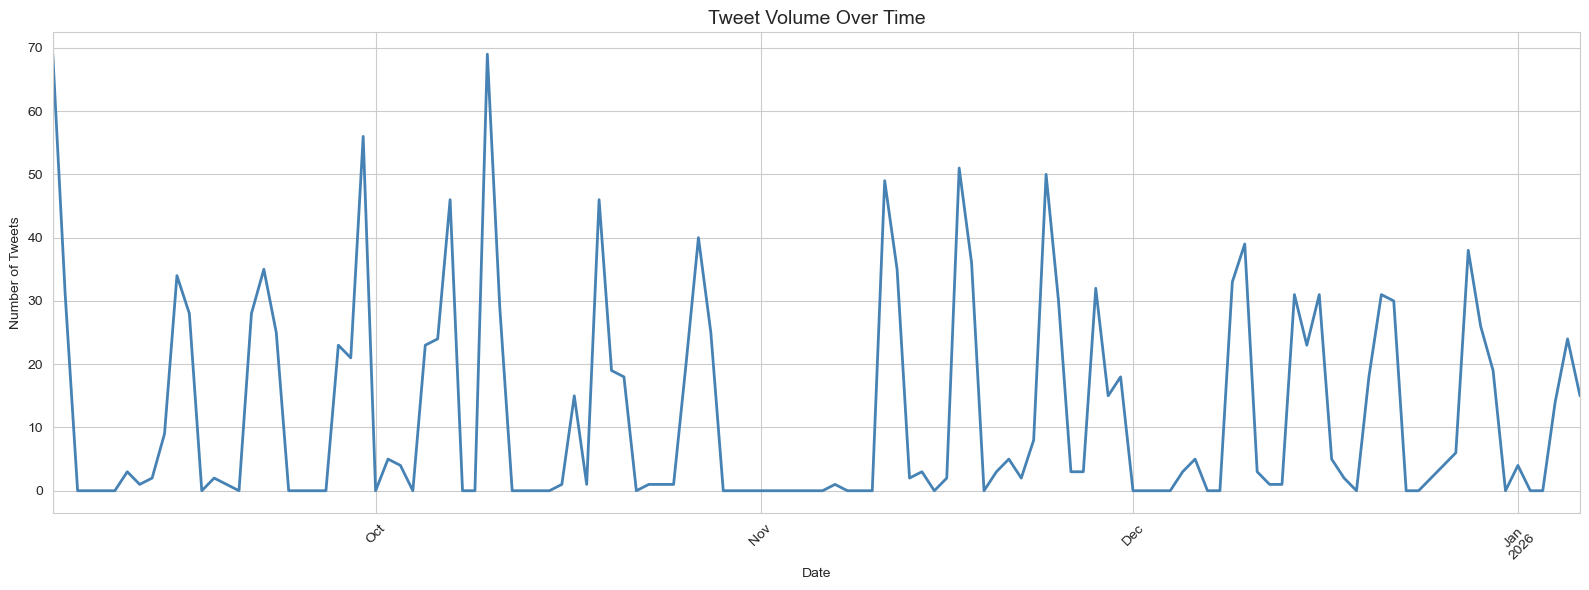

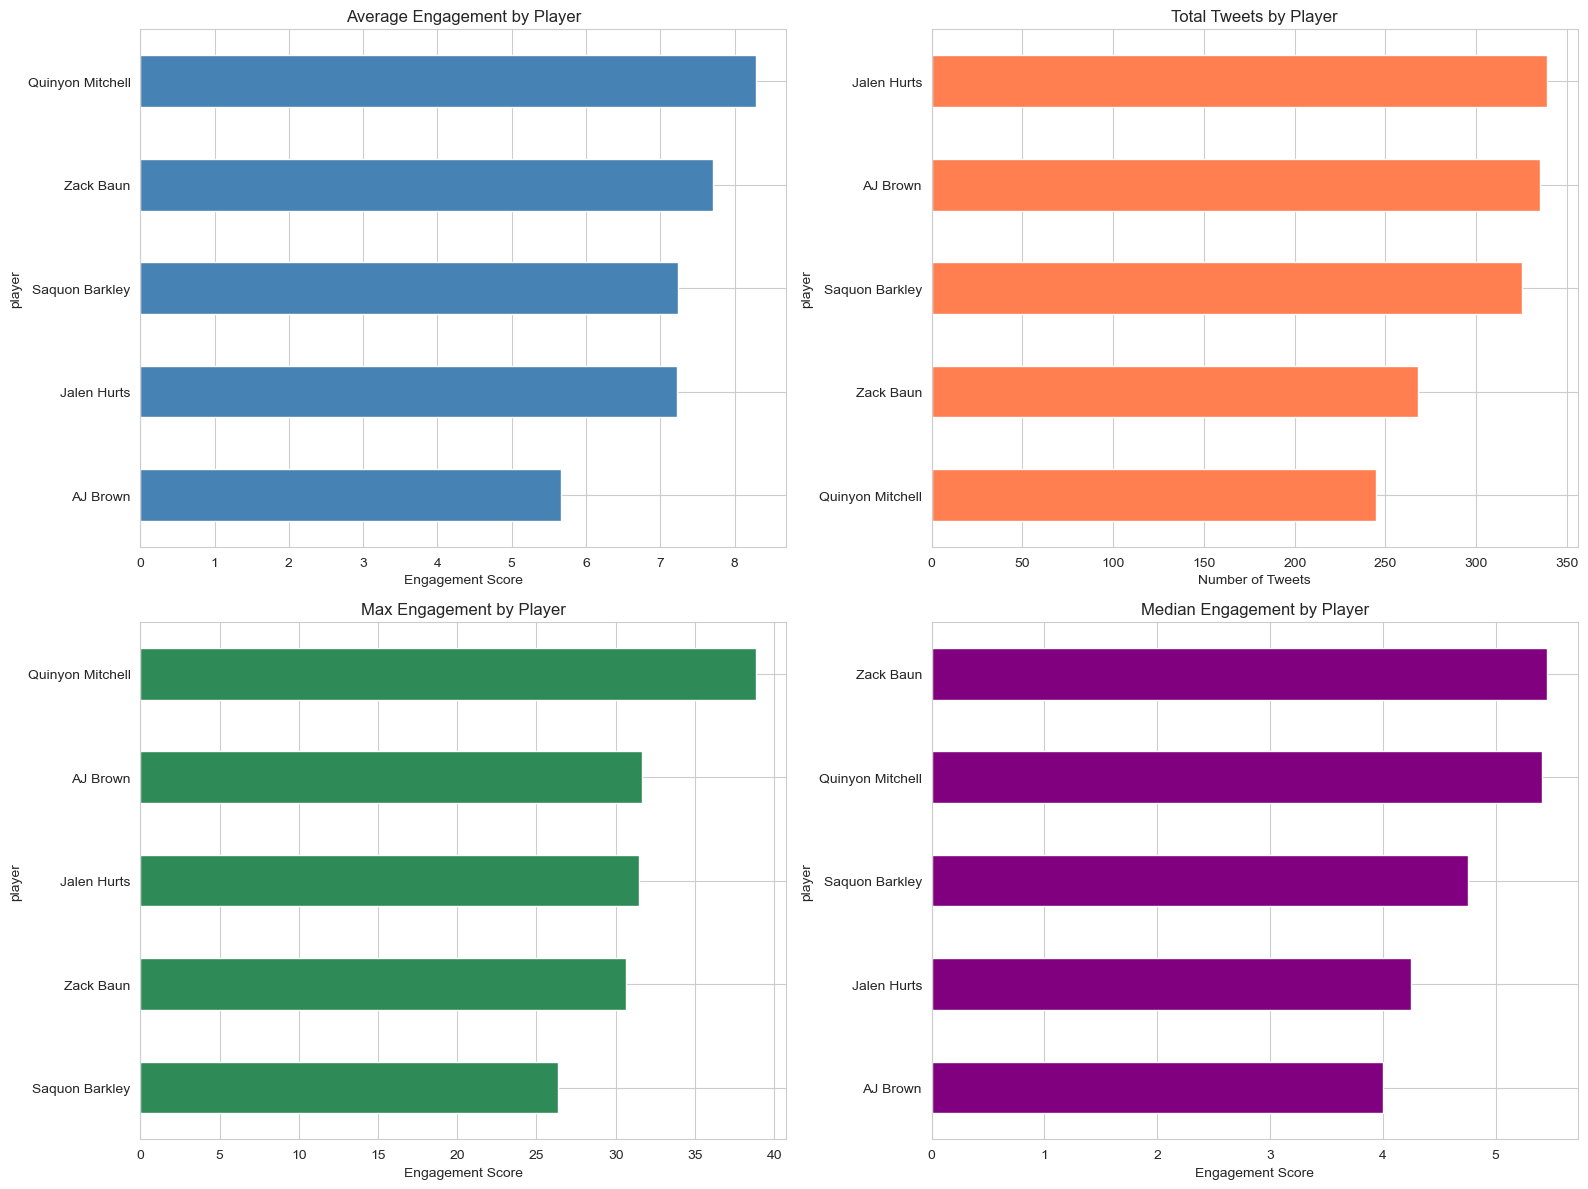

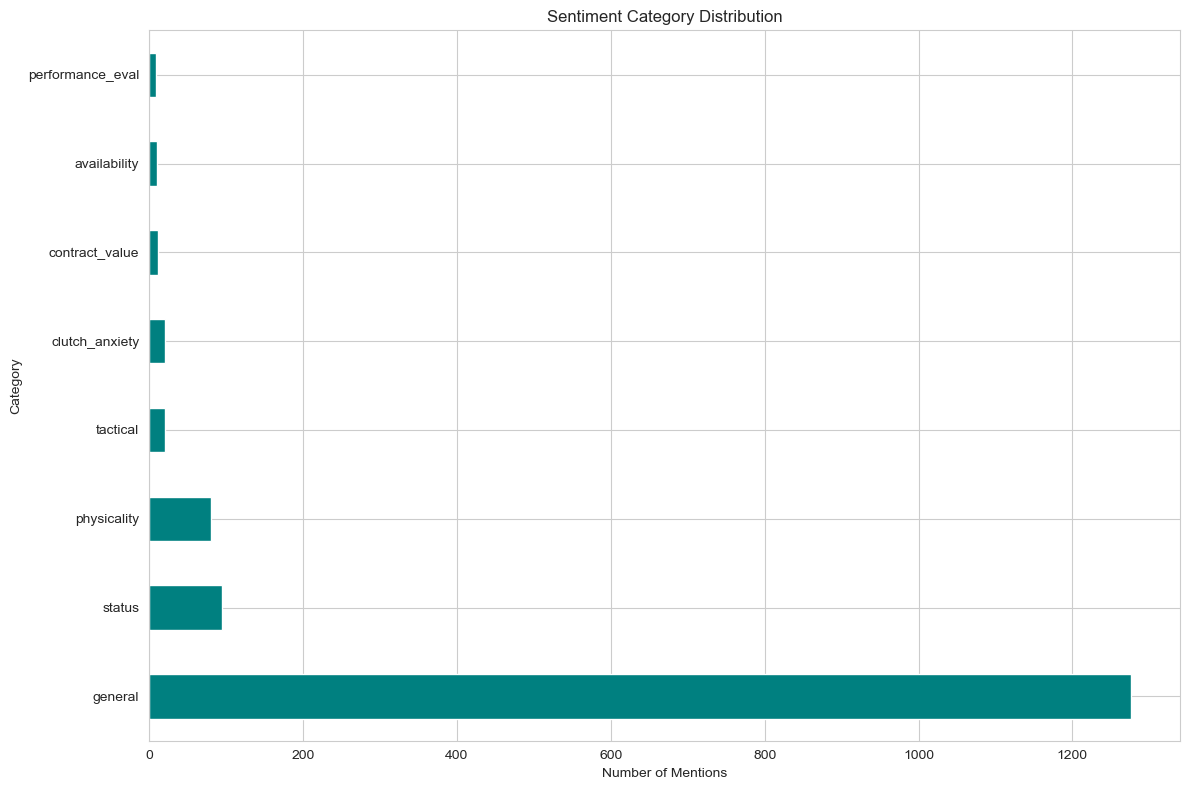

/var/folders/5w/wqg3d8mj5xbb7jj6cc1hx8vc0000gn/T/ipykernel_86682/1904382936.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


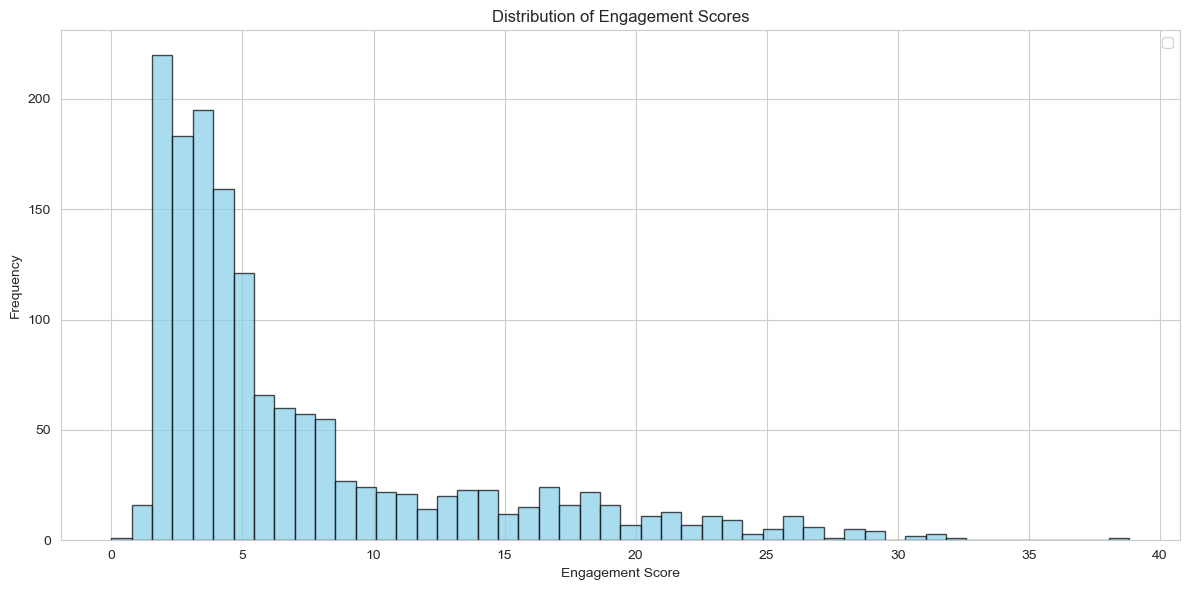

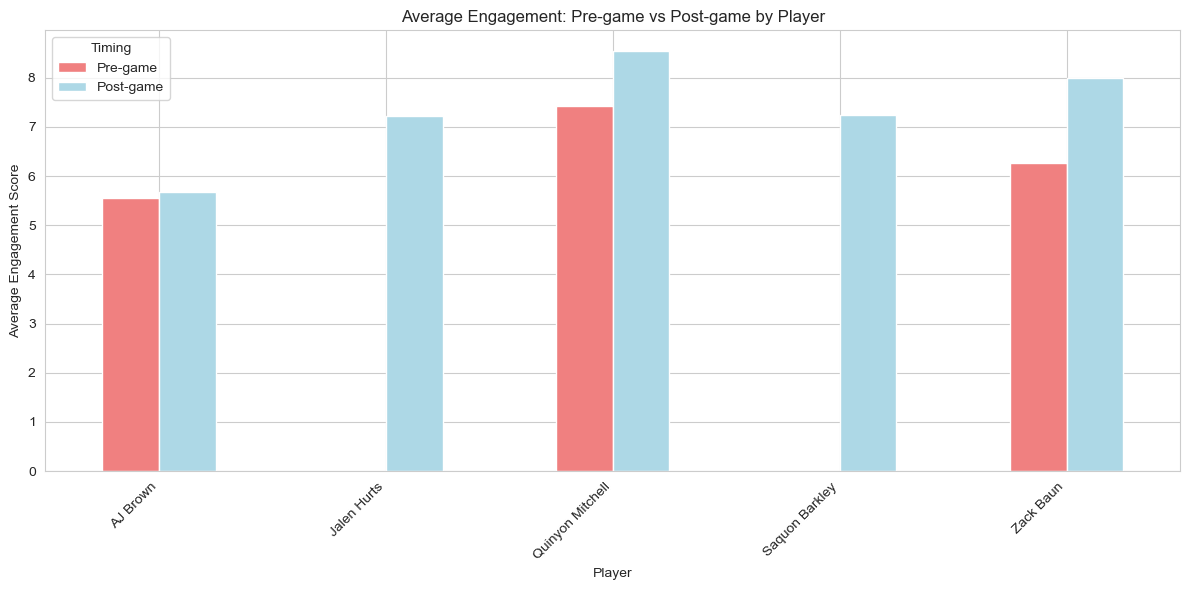

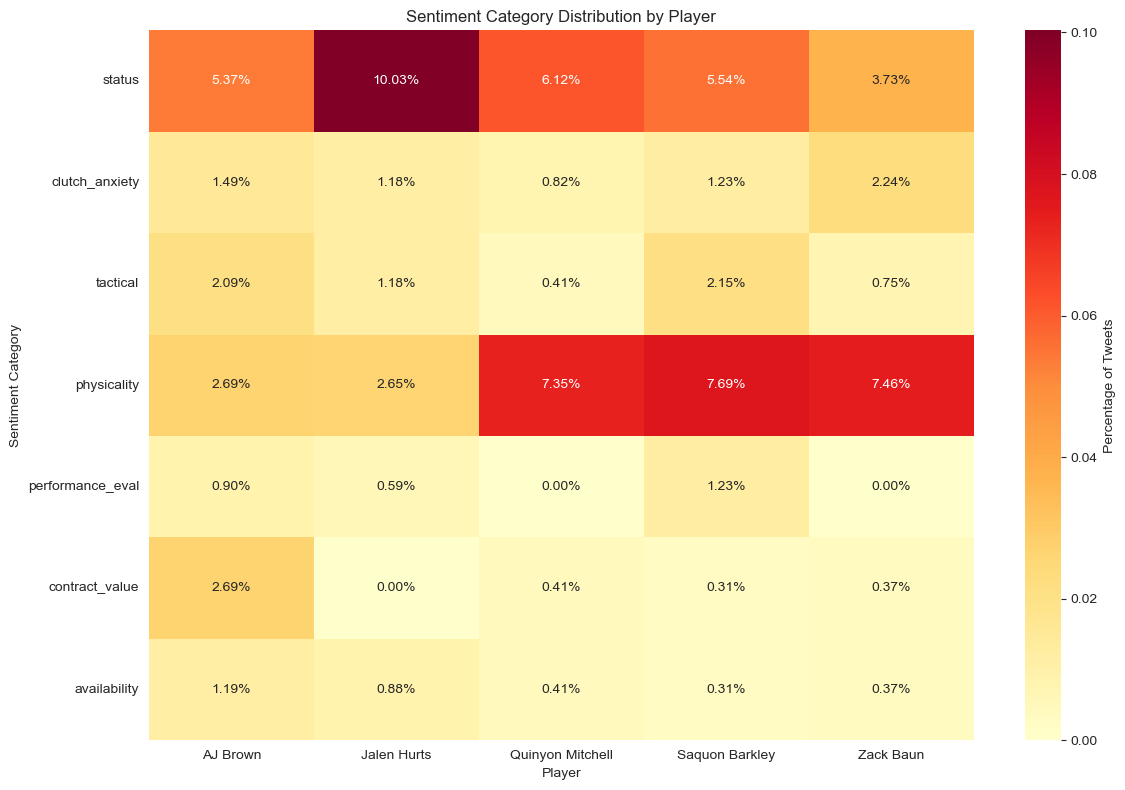

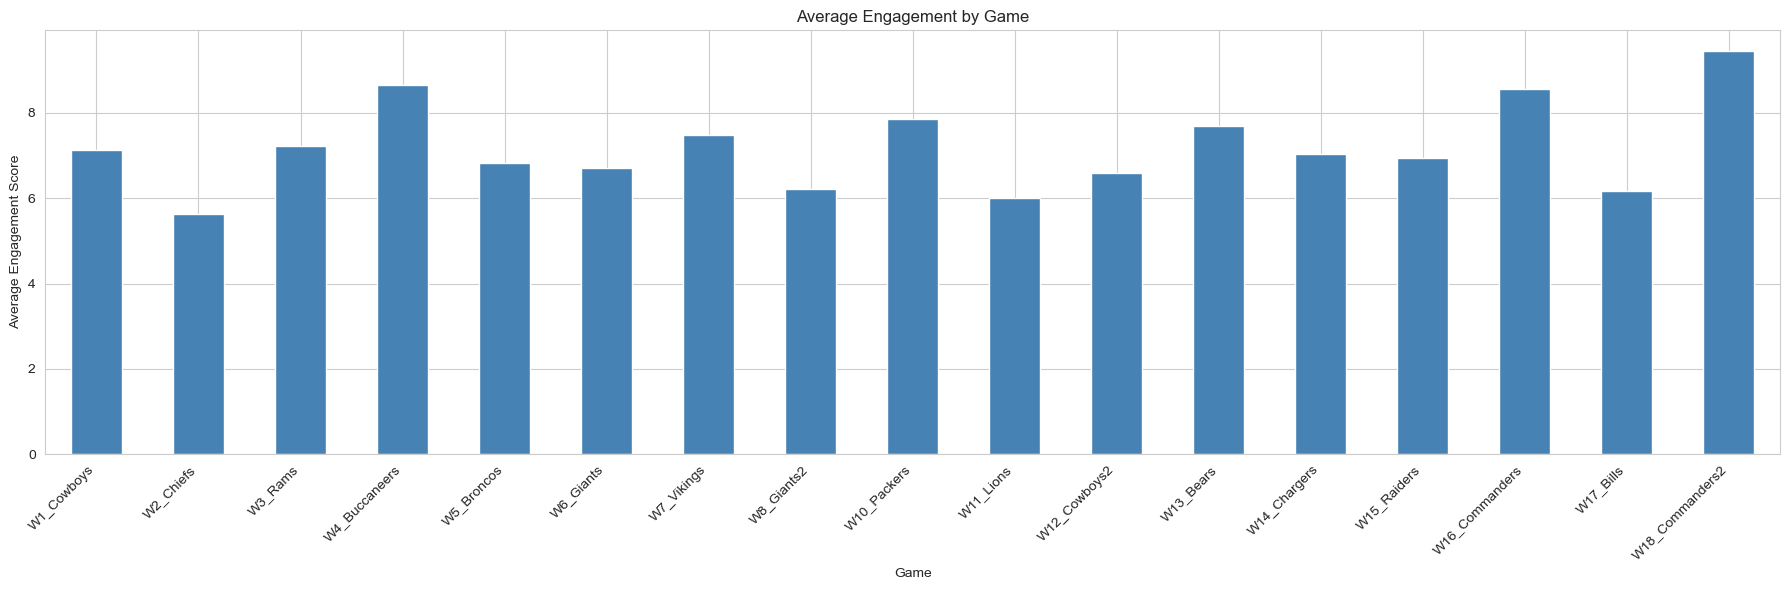

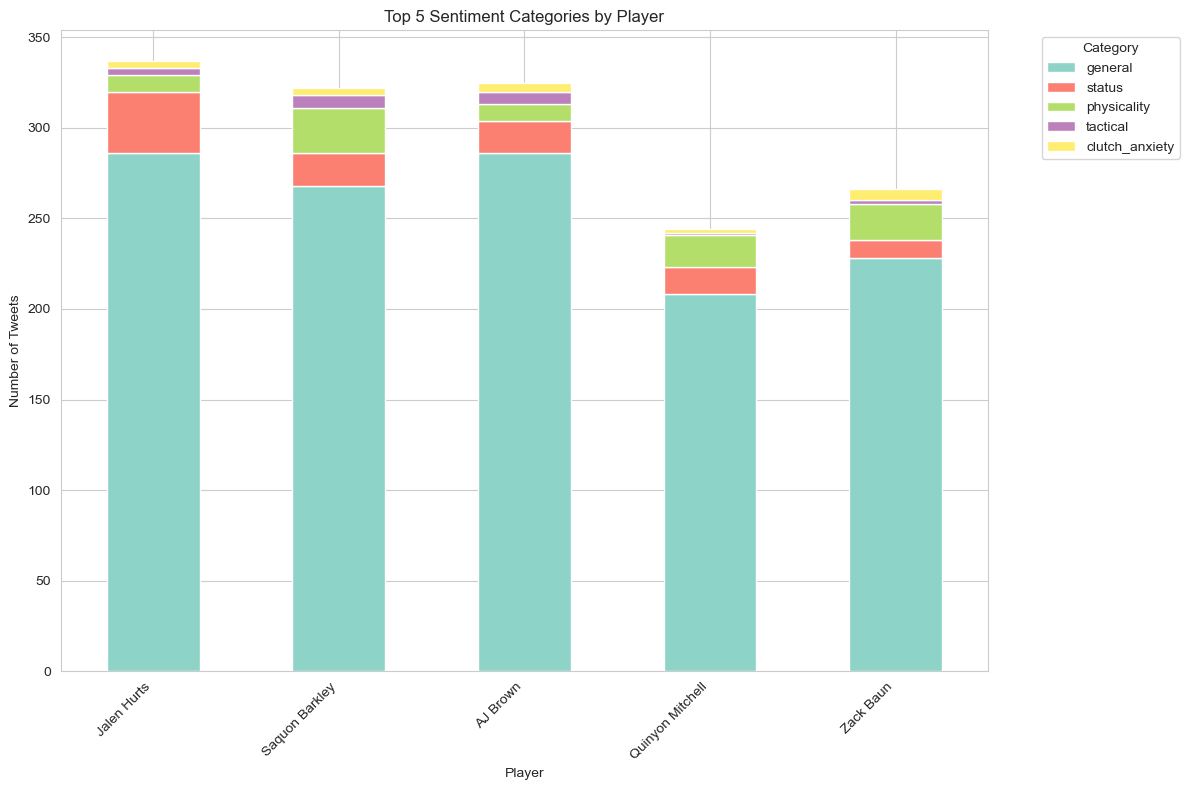

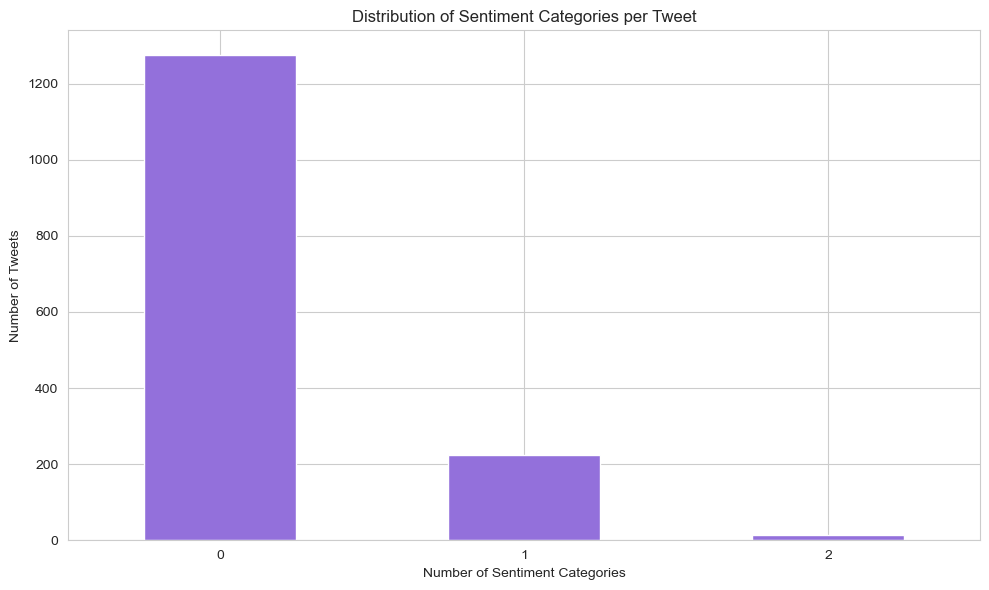

In [17]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

df = pd.read_csv('eagles_sentiment_2025_26_corrected.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
df['game_date'] = pd.to_datetime(df['game_date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}\n")

print(df[['likes', 'retweets', 'replies', 'engagement_score']].describe())

print("\nTweets per player:")
print(df['player'].value_counts())

print("\nEngagement per player:")
player_engagement = df.groupby('player')['engagement_score'].agg(['mean', 'median', 'max', 'count']).sort_values('mean', ascending=False)
print(player_engagement)

print("\nTweets per game:")
game_counts = df['game_id'].value_counts().sort_index()
print(game_counts)

print("\nPre vs Post game:")
print(df['is_post_game'].value_counts())
pre_post_engagement = df.groupby('is_post_game')['engagement_score'].agg(['mean', 'median', 'count'])
pre_post_engagement.index = ['Pre-game', 'Post-game']
print(pre_post_engagement)

all_categories = []
for cats in df['sentiment_categories']:
    if pd.notna(cats):
        all_categories.extend(cats.split(','))

category_counts = pd.Series(all_categories).value_counts()
print("\nSentiment category mentions:")
print(category_counts)

df['num_categories'] = df['sentiment_categories'].str.count(',') + 1
df.loc[df['sentiment_categories'] == 'general', 'num_categories'] = 0

print("\nVerified account stats:")
verified_stats = df.groupby('verified').agg({
    'engagement_score': ['mean', 'median', 'count'],
    'likes': 'mean',
    'retweets': 'mean'
})
print(verified_stats)

print("\nTop 5 tweets by engagement:")
top_tweets = df.nlargest(5, 'engagement_score')[['player', 'game_id', 'engagement_score', 'sentiment_categories', 'text']]
for idx, row in top_tweets.iterrows():
    print(f"\n{row['player']} | {row['game_id']} | Engagement: {row['engagement_score']:.0f}")
    print(f"Sentiment: {row['sentiment_categories']}")
    print(f"{row['text'][:150]}...")

# Tweet volume over time
fig, ax = plt.subplots(figsize=(16, 6))
df.sort_values('created_at').set_index('created_at').resample('D')['text'].count().plot(ax=ax, linewidth=2, color='steelblue')
plt.title('Tweet Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Player engagement metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df.groupby('player')['engagement_score'].mean().sort_values(ascending=True).plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average Engagement by Player')
axes[0, 0].set_xlabel('Engagement Score')

df['player'].value_counts().sort_values(ascending=True).plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Total Tweets by Player')
axes[0, 1].set_xlabel('Number of Tweets')

df.groupby('player')['engagement_score'].max().sort_values(ascending=True).plot(kind='barh', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Max Engagement by Player')
axes[1, 0].set_xlabel('Engagement Score')

df.groupby('player')['engagement_score'].median().sort_values(ascending=True).plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Median Engagement by Player')
axes[1, 1].set_xlabel('Engagement Score')

plt.tight_layout()
plt.show()

# Sentiment distribution
fig, ax = plt.subplots(figsize=(12, 8))
category_counts.plot(kind='barh', ax=ax, color='teal')
plt.title('Sentiment Category Distribution')
plt.xlabel('Number of Mentions')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Engagement distribution
fig, ax = plt.subplots(figsize=(12, 6))
df['engagement_score'].hist(bins=50, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
# plt.axvline(df['engagement_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["engagement_score"].mean():.1f}')
# plt.axvline(df['engagement_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["engagement_score"].median():.1f}')
plt.title('Distribution of Engagement Scores')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Pre vs Post game by player
fig, ax = plt.subplots(figsize=(12, 6))
pre_post_player = df.groupby(['player', 'is_post_game'])['engagement_score'].mean().unstack()
pre_post_player.columns = ['Pre-game', 'Post-game']
pre_post_player.plot(kind='bar', ax=ax, color=['lightcoral', 'lightblue'])
plt.title('Average Engagement: Pre-game vs Post-game by Player')
plt.xlabel('Player')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Timing')
plt.tight_layout()
plt.show()

# Sentiment heatmap by player
sentiment_filters = {
    "status": None, "clutch_anxiety": None, "tactical": None, "physicality": None,
    "performance_eval": None, "contract_value": None, "availability": None
}

for category in sentiment_filters.keys():
    df[f'has_{category}'] = df['sentiment_categories'].str.contains(category, na=False)

sentiment_by_player = df.groupby('player')[[f'has_{cat}' for cat in sentiment_filters.keys()]].mean()
sentiment_by_player.columns = list(sentiment_filters.keys())

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(sentiment_by_player.T, annot=True, fmt='.2%', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Percentage of Tweets'})
plt.title('Sentiment Category Distribution by Player')
plt.xlabel('Player')
plt.ylabel('Sentiment Category')
plt.tight_layout()
plt.show()

# Game-by-game engagement
fig, ax = plt.subplots(figsize=(18, 6))
game_engagement_plot = df.groupby('game_id')['engagement_score'].mean()
game_order = sorted(df['game_id'].unique(), key=lambda x: int(x.split('_')[0][1:]))
game_engagement_plot = game_engagement_plot.reindex(game_order)
game_engagement_plot.plot(kind='bar', ax=ax, color='steelblue')
plt.title('Average Engagement by Game')
plt.xlabel('Game')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Stacked sentiment by player
top_n_categories = 5
top_categories = category_counts.head(top_n_categories).index

player_category_matrix = pd.DataFrame()
for player in df['player'].unique():
    player_data = df[df['player'] == player]
    category_dist = {cat: player_data['sentiment_categories'].str.contains(cat, na=False).sum() for cat in top_categories}
    player_category_matrix[player] = pd.Series(category_dist)

fig, ax = plt.subplots(figsize=(12, 8))
player_category_matrix.T.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
plt.title(f'Top {top_n_categories} Sentiment Categories by Player')
plt.xlabel('Player')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Categories per tweet
fig, ax = plt.subplots(figsize=(10, 6))
df['num_categories'].value_counts().sort_index().plot(kind='bar', ax=ax, color='mediumpurple')
plt.title('Distribution of Sentiment Categories per Tweet')
plt.xlabel('Number of Sentiment Categories')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Reddit Data

In [4]:
reddit_df = pd.read_csv("data/reddit_sentiment.csv")
reddit_df.head()

,post_title,subreddit,post_id,link_fullname,comment_id,comment_fullname,parent_fullname,depth,author,body,score,created_utc,permalink,edited,distinguished,gilded,is_submitter,stickied,locked,collapsed
0,Post Game Thread: Washington Commanders at Phi...,nfl,1q46mfl,t3_1q46mfl,nxq7jlu,t1_nxq7jlu,t3_1q46mfl,0,pam-halpert,At least this will silence the McKee truthers…...,166,1.767573e+09,/r/nfl/comments/1q46mfl/post_game_thread_washi...,NaN,NaN,0,False,False,False,False
1,Post Game Thread: Washington Commanders at Phi...,nfl,1q46mfl,t3_1q46mfl,nxq7hmt,t1_nxq7hmt,t3_1q46mfl,0,InterestingBother756,YOU FUCKING IDIOTSSSSSSSS,301,1.767573e+09,/r/nfl/comments/1q46mfl/post_game_thread_washi...,NaN,NaN,0,False,False,False,False
2,Post Game Thread: Washington Commanders at Phi...,nfl,1q46mfl,t3_1q46mfl,nxq7jxj,t1_nxq7jxj,t3_1q46mfl,0,[deleted],Eagles didn’t believe in the Lions lol. (I did...,70,1.767573e+09,/r/nfl/comments/1q46mfl/post_game_thread_washi...,NaN,NaN,0,False,False,False,False
3,Post Game Thread: Washington Commanders at Phi...,nfl,1q46mfl,t3_1q46mfl,nxq7h68,t1_nxq7h68,t3_1q46mfl,0,prismatic_lights,"Don't cry because it happened, smile because i...",182,1.767573e+09,/r/nfl/comments/1q46mfl/post_game_thread_washi...,NaN,NaN,0,False,False,False,False
4,Post Game Thread: Washington Commanders at Phi...,nfl,1q46mfl,t3_1q46mfl,nxq7htm,t1_nxq7htm,t3_1q46mfl,0,zincinzincout,Have to think the eagles wanted to lose with h...,151,1.767573e+09,/r/nfl/comments/1q46mfl/post_game_thread_washi...,NaN,NaN,0,False,False,False,False


In [5]:
reddit_df = reddit_df[['post_title', 'depth', 'body', 'score', 'created_utc']]
reddit_df.head()

,post_title,depth,body,score,created_utc
0,Post Game Thread: Washington Commanders at Phi...,0,At least this will silence the McKee truthers…...,166,1.767573e+09
1,Post Game Thread: Washington Commanders at Phi...,0,YOU FUCKING IDIOTSSSSSSSS,301,1.767573e+09
2,Post Game Thread: Washington Commanders at Phi...,0,Eagles didn’t believe in the Lions lol. (I did...,70,1.767573e+09
3,Post Game Thread: Washington Commanders at Phi...,0,"Don't cry because it happened, smile because i...",182,1.767573e+09
4,Post Game Thread: Washington Commanders at Phi...,0,Have to think the eagles wanted to lose with h...,151,1.767573e+09


In [17]:
print(reddit_df['post_title'].unique())

['Post Game Thread: Washington Commanders at Philadelphia Eagles'
 'Post Game Thread: Dallas Cowboys at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at Kansas City Chiefs'
 'Post Game Thread: Los Angeles Rams at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at Tampa Bay Buccaneers'
 'Post Game Thread: Denver Broncos at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at New York Giants'
 'Post Game Thread: Philadelphia Eagles at Minnesota Vikings'
 'Post Game Thread: New York Giants at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at Green Bay Packers'
 'Post Game Thread: Detroit Lions at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at Dallas Cowboys'
 'Post Game Thread: Chicago Bears at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at Los Angeles Chargers'
 'Post Game Thread: Las Vegas Raiders at Philadelphia Eagles'
 'Post Game Thread: Philadelphia Eagles at Washington Commanders'
 'Post Game Thr

In [6]:
week_dict = {
    'Post Game Thread: Washington Commanders at Philadelphia Eagles': 18,
    'Post Game Thread: Dallas Cowboys at Philadelphia Eagles': 1,
    'Post Game Thread: Philadelphia Eagles at Kansas City Chiefs': 2,
    'Post Game Thread: Los Angeles Rams at Philadelphia Eagles': 3,
    'Post Game Thread: Philadelphia Eagles at Tampa Bay Buccaneers': 4, 
    'Post Game Thread: Denver Broncos at Philadelphia Eagles': 5,
    'Post Game Thread: Philadelphia Eagles at New York Giants': 6,
    'Post Game Thread: Philadelphia Eagles at Minnesota Vikings': 7,
    'Post Game Thread: New York Giants at Philadelphia Eagles': 8,
    'Post Game Thread: Philadelphia Eagles at Green Bay Packers': 10,
    'Post Game Thread: Detroit Lions at Philadelphia Eagles': 11,
    'Post Game Thread: Philadelphia Eagles at Dallas Cowboys': 12,
    'Post Game Thread: Chicago Bears at Philadelphia Eagles': 13,
    'Post Game Thread: Philadelphia Eagles at Los Angeles Chargers': 14,
    'Post Game Thread: Las Vegas Raiders at Philadelphia Eagles': 15,
    'Post Game Thread: Philadelphia Eagles at Washington Commanders': 16,
    'Post Game Thread: Philadelphia Eagles at Buffalo Bills': 17
}

reddit_df['week'] = reddit_df['post_title'].map(week_dict)

In [8]:
reddit_df['depth'].value_counts()

depth
0    1143
1    1101
2     715
3     390
4     143
5      62
6       7
Name: count, dtype: int64

I'm assuming depth is the "recursive" comment depth - i.e. depth 2 means it is responding to a response to a comment

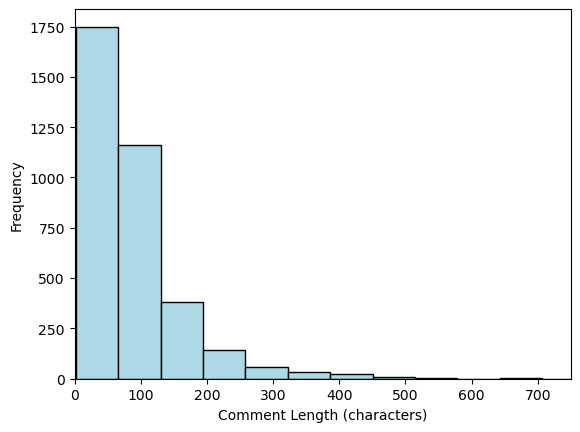

In [12]:
reddit_df['comment_length'] = reddit_df['body'].str.len()
plt.hist(reddit_df['comment_length'], bins=30, color='lightblue', edgecolor='black')
plt.xlim(0, 750)
plt.xlabel('Comment Length (characters)')
plt.ylabel('Frequency')
plt.show()

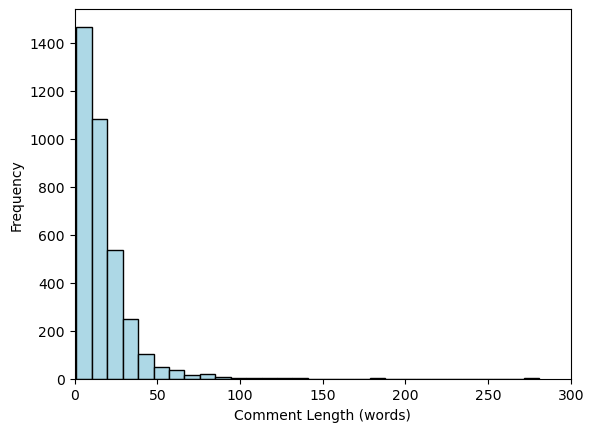

In [14]:
reddit_df['comment_length_words'] = reddit_df['body'].str.split().str.len()
plt.hist(reddit_df['comment_length_words'], bins=30, color='lightblue', edgecolor='black')
plt.xlim(0, 300)
plt.xlabel('Comment Length (words)')
plt.ylabel('Frequency')
plt.show()

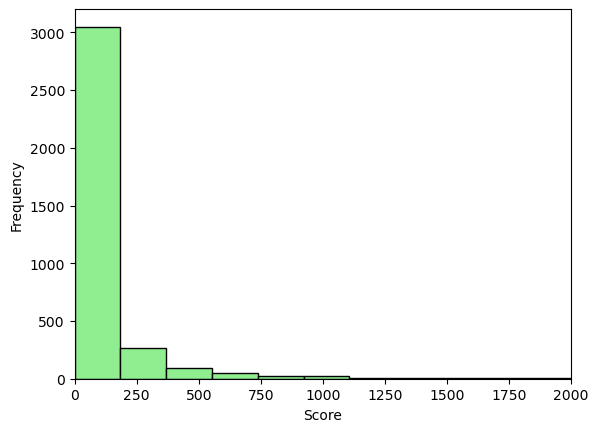

In [16]:
plt.hist(reddit_df['score'], bins=30, color='lightgreen', edgecolor='black')
plt.xlim(0, 2000)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

Pretty much all of the univariate distributions are right skewed (but these just have to do with the length and structure of the comments, not necessarily their sentimental charge/value)

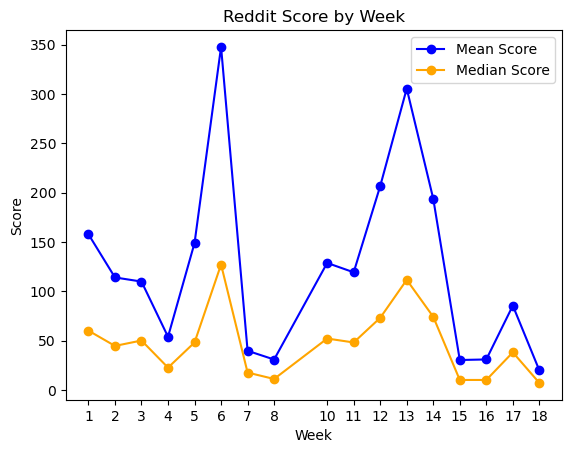

In [20]:
reddit_score_by_week = reddit_df.groupby('week').agg({
    'score': ['mean', 'median']
})

plt.plot(reddit_score_by_week.index, reddit_score_by_week['score']['mean'], marker='o', label='Mean Score', color='blue')
plt.plot(reddit_score_by_week.index, reddit_score_by_week['score']['median'], marker='o', label='Median Score', color='orange')
plt.xticks(reddit_score_by_week.index)
plt.xlabel('Week')
plt.ylabel('Score')
plt.title('Reddit Score by Week')
plt.legend()
plt.show()

We see spikes in scores for close/controversial games: Week 6 is loss to Giants, Week 13 is win against Bears, Week 17 is win against Bills

Would be interseting to plot against some measure of opposing team strength (like DVOA measures from atheltic performance data) to see if score goes up in "harder" games. Also maybe against divisional opponents.

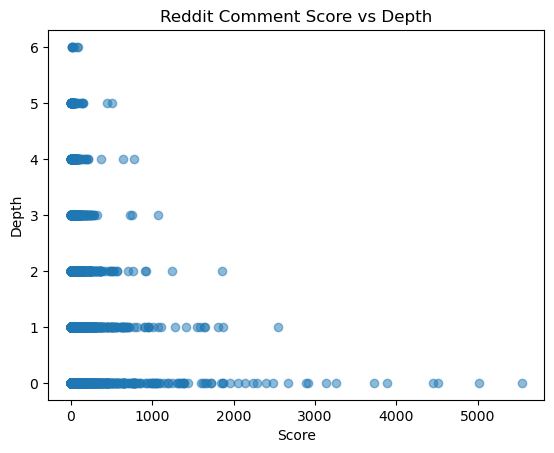

In [21]:
plt.scatter(reddit_df['score'], reddit_df['depth'], alpha=0.5)
plt.xlabel('Score')
plt.ylabel('Depth')
plt.title('Reddit Comment Score vs Depth')
plt.show()

The higher up in comment hierarchy it is, the higher score it is (is score just upvotes? upvotes - downvotes?)

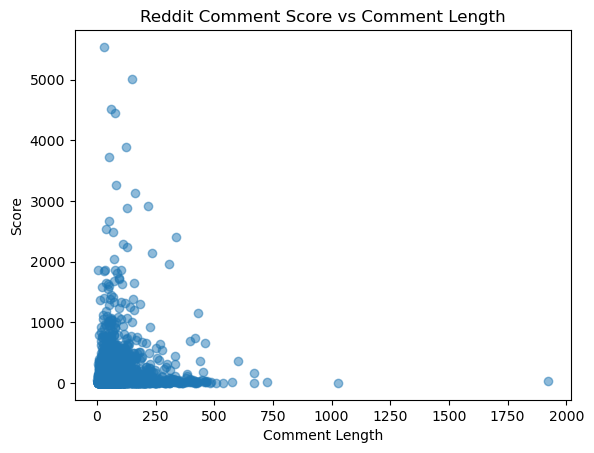

In [22]:
plt.scatter(reddit_df['comment_length'], reddit_df['score'], alpha=0.5)
plt.xlabel('Comment Length')
plt.ylabel('Score')
plt.title('Reddit Comment Score vs Comment Length')
plt.show()

Shorter comments actually tend to score better

## Sentiment Dictionary Approach

In [7]:
hiv4 = ps.HIV4()
scores = []

for comment in reddit_df['body']:
    tokens = hiv4.tokenize(comment)
    score = hiv4.get_score(tokens)
    scores.append(score)

In [8]:
reddit_df['hiv4_pos_sentiment_count'] = [score['Positive'] for score in scores]
reddit_df['hiv4_neg_sentiment_count'] = [score['Negative'] for score in scores]

In [10]:
lm = ps.LM()
scores = []

for comment in reddit_df['body']:
    tokens = lm.tokenize(comment)
    score = lm.get_score(tokens)
    scores.append(score)

In [11]:
reddit_df['lm_pos_sentiment_count'] = [score['Positive'] for score in scores]
reddit_df['lm_neg_sentiment_count'] = [score['Negative'] for score in scores]

/tmp/ipykernel_1344/3235750743.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([reddit_df['hiv4_pos_sentiment_count'], reddit_df['hiv4_neg_sentiment_count']], labels=['Positive', 'Negative'])


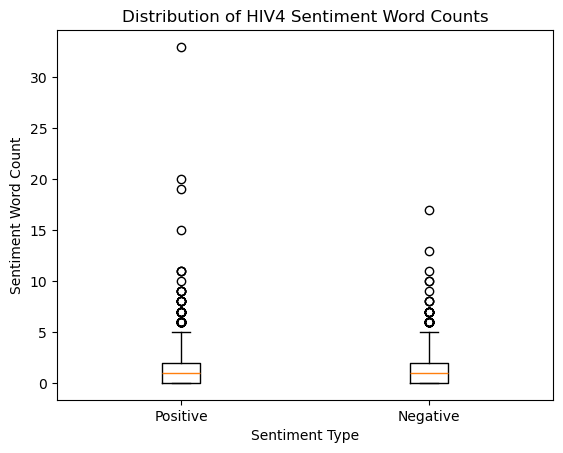

In [33]:
plt.boxplot([reddit_df['hiv4_pos_sentiment_count'], reddit_df['hiv4_neg_sentiment_count']], labels=['Positive', 'Negative'])
plt.xlabel('Sentiment Type')
plt.ylabel('Sentiment Word Count')
plt.title('Distribution of HIV4 Sentiment Word Counts')
plt.show()

/tmp/ipykernel_1344/3129022706.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([reddit_df['lm_pos_sentiment_count'], reddit_df['lm_neg_sentiment_count']], labels=['Positive', 'Negative'])


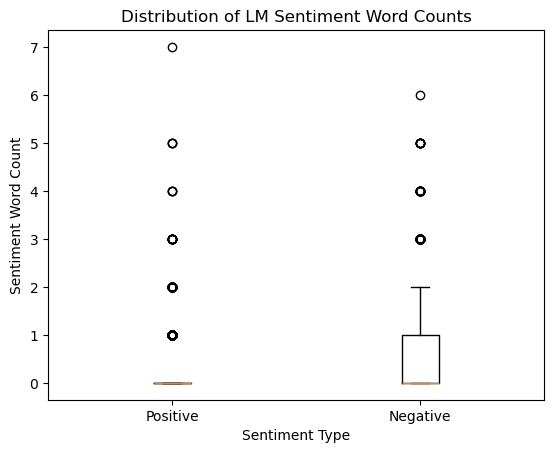

In [34]:
plt.boxplot([reddit_df['lm_pos_sentiment_count'], reddit_df['lm_neg_sentiment_count']], labels=['Positive', 'Negative'])
plt.xlabel('Sentiment Type')
plt.ylabel('Sentiment Word Count')
plt.title('Distribution of LM Sentiment Word Counts')
plt.show()

Very different distributions based on HIV4 (general psychological) dictionary or Loughran and McDonald (financial) dictionary

In [12]:
reddit_sentiment_by_week = reddit_df.groupby('week').agg({
    'hiv4_pos_sentiment_count': 'mean',
    'hiv4_neg_sentiment_count': 'mean',
    'lm_pos_sentiment_count': 'mean',
    'lm_neg_sentiment_count': 'mean'
}).reset_index()

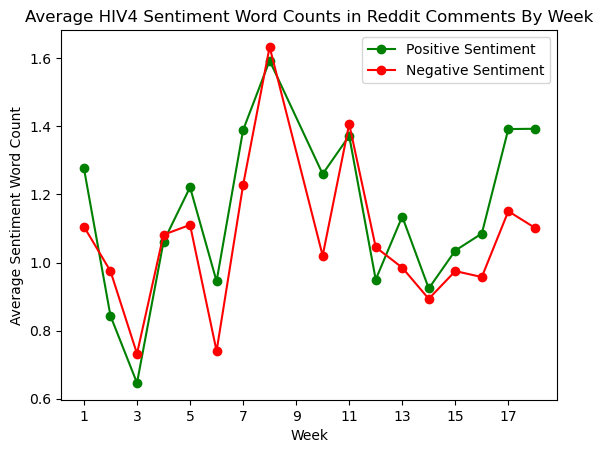

In [14]:
plt.plot(reddit_sentiment_by_week['week'], reddit_sentiment_by_week['hiv4_pos_sentiment_count'], marker='o', color='green', label='Positive Sentiment')
plt.plot(reddit_sentiment_by_week['week'], reddit_sentiment_by_week['hiv4_neg_sentiment_count'], marker='o', color='red', label='Negative Sentiment')
plt.xlabel('Week')
plt.ylabel('Average Sentiment Word Count')
plt.title('Average HIV4 Sentiment Word Counts in Reddit Comments By Week')
plt.xticks(range(1, 18, 2))
plt.legend()
plt.show()

Based on just the Harvard IV4 dictionary, there is not a big difference in the frequency of positive or negative words. Both more or less follow score by week (even though we're looking at the average sentiment word count). Looks fairly similar to Jalen Hurts passing yards by week plot

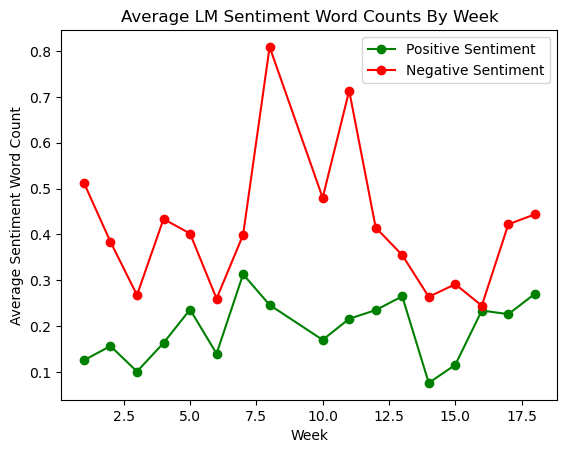

In [36]:
plt.plot(reddit_sentiment_by_week['week'], reddit_sentiment_by_week['lm_pos_sentiment_count'], marker='o', color='green', label='Positive Sentiment')
plt.plot(reddit_sentiment_by_week['week'], reddit_sentiment_by_week['lm_neg_sentiment_count'], marker='o', color='red', label='Negative Sentiment')
plt.xlabel('Week')
plt.ylabel('Average Sentiment Word Count')
plt.title('Average LM Sentiment Word Counts By Week')
plt.legend()
plt.show()

Using the Loughran and McDonald dictionary, much fewer words are identified as containing positive or negative sentiment, but many more negative words than positive words. With this being a specifically financial dictionary, it may not be the best comparison (HIV4 may be better)

In [6]:
players = [
    'jalen', 'hurts', 'saquon', 'barkley', 'aj', 'a.j.', 'aj brown', 'a.j. brown', 'devonta', 'smith',
    'baun', 'quinyon', 'mitchell'    
]

reddit_df['contains_player_name'] = reddit_df['body'].str.contains('|'.join(players), case=False, na=False)
reddit_df.head()

,post_title,depth,body,score,created_utc,week,contains_player_name
0,Post Game Thread: Washington Commanders at Phi...,0,At least this will silence the McKee truthers…...,166,1.767573e+09,18,False
1,Post Game Thread: Washington Commanders at Phi...,0,YOU FUCKING IDIOTSSSSSSSS,301,1.767573e+09,18,False
2,Post Game Thread: Washington Commanders at Phi...,0,Eagles didn’t believe in the Lions lol. (I did...,70,1.767573e+09,18,False
3,Post Game Thread: Washington Commanders at Phi...,0,"Don't cry because it happened, smile because i...",182,1.767573e+09,18,False
4,Post Game Thread: Washington Commanders at Phi...,0,Have to think the eagles wanted to lose with h...,151,1.767573e+09,18,False


In [ ]:
reddit_df['contains_player_name'].value_counts()
reddit_df[reddit_df['contains_player_name'] == True][['body', 'score']].head(10)

,body,score
15,This game has done more for hurts' legacy than...,32
22,After having to hear all offseason and even ea...,6
45,Fangio is a miracle worker for making Adoree J...,3
100,Our OC is dumber than a bag of bricks which is...,10
130,"And if Hurts or AJ got hurt today, there would...",3
142,The amount of time the announcers said “and th...,13
183,A big reason Nick probably made the decision i...,3
198,The most important part of this game was learn...,1626
215,AJ Brown AND Devonta Smith as luxuries is insane.,60
220,Jalen Carter is the real winner in all of this...,75


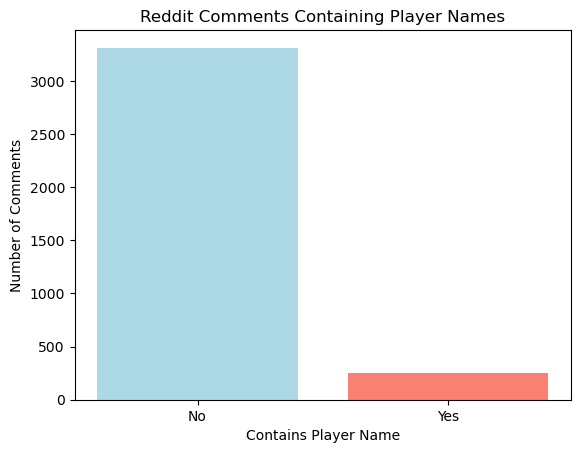

In [11]:
plt.bar(reddit_df['contains_player_name'].value_counts().index, reddit_df['contains_player_name'].value_counts().values, color=['lightblue', 'salmon'])
plt.xlabel('Contains Player Name')
plt.ylabel('Number of Comments')
plt.title('Reddit Comments Containing Player Names')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [13]:
reddit_player_by_week = reddit_df.groupby(['week', 'contains_player_name']).agg({
    'score': 'mean'
}).reset_index()

reddit_player_by_week_count = reddit_df.groupby(['week', 'contains_player_name']).size().reset_index(name='count')
reddit_player_by_week['count'] = reddit_player_by_week_count['count']

reddit_player_by_week.head()

,week,contains_player_name,score,count
0,1,False,154.372973,185
1,1,True,201.571429,14
2,2,False,112.043011,186
3,2,True,143.000000,12
4,3,False,114.761364,176


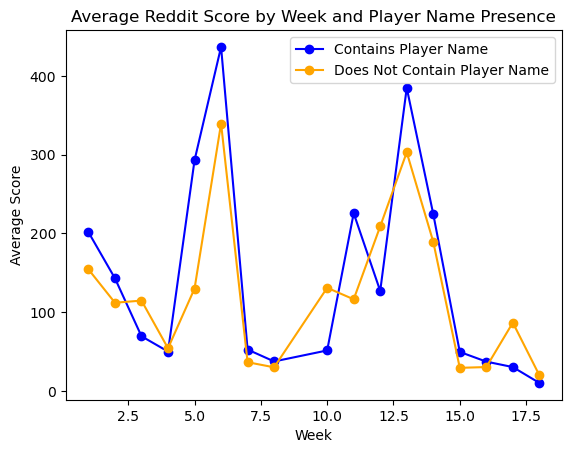

In [14]:
plt.plot(reddit_player_by_week[reddit_player_by_week['contains_player_name'] == True]['week'], reddit_player_by_week[reddit_player_by_week['contains_player_name'] == True]['score'], marker='o', color='blue', label='Contains Player Name')
plt.plot(reddit_player_by_week[reddit_player_by_week['contains_player_name'] == False]['week'], reddit_player_by_week[reddit_player_by_week['contains_player_name'] == False]['score'], marker='o', color='orange', label='Does Not Contain Player Name')
plt.xlabel('Week')
plt.ylabel('Average Score')
plt.title('Average Reddit Score by Week and Player Name Presence')
plt.legend()
plt.show()

Reddit comments that specifically mention a player don't necessarily score better

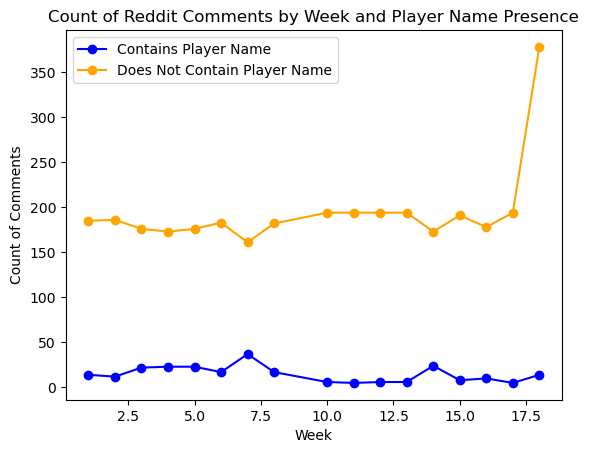

In [15]:
plt.plot(reddit_player_by_week[reddit_player_by_week['contains_player_name'] == True]['week'], reddit_player_by_week[reddit_player_by_week['contains_player_name'] == True]['count'], marker='o', color='blue', label='Contains Player Name')
plt.plot(reddit_player_by_week[reddit_player_by_week['contains_player_name'] == False]['week'], reddit_player_by_week[reddit_player_by_week['contains_player_name'] == False]['count'], marker='o', color='orange', label='Does Not Contain Player Name')
plt.xlabel('Week')
plt.ylabel('Count of Comments')
plt.title('Count of Reddit Comments by Week and Player Name Presence')
plt.legend()
plt.show()

Majority of comments do not mention a player by name, so we cannot necessarily attribute them to a specific player. Likely use Reddit for team level sentiment

# Google Articles

In [3]:
google_df = pd.read_csv("data/eagles_2025_articles_non_paywalled.csv")
google_df.head()

,week,game_date,opponent,home_away,query,source,author,title,text_body,url
0,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...
1,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Yahoo Sports,NaN,"Cowboys vs. Eagles odds, predictions: Best bet...","Story by Matt Russell Contributing writer Thu,...",https://sports.yahoo.com/nfl/betting/article/c...
2,2,9/14/25,Kansas City Chiefs,away,"Philadelphia Eagles at ""Kansas City Chiefs"" 20...",Philadelphia Eagles,NaN,"Game Recap: Eagles 20, Chiefs 17 | September 1...","Game Recap: Eagles 20, Chiefs 17 | September 1...",https://www.philadelphiaeagles.com/news/eagles...
3,2,9/14/25,Kansas City Chiefs,away,"Philadelphia Eagles at ""Kansas City Chiefs"" 20...",Philadelphia Eagles,NaN,Spadaro: 10 observations from a dramatic win o...,Spadaro: 10 observations from a dramatic win o...,https://www.philadelphiaeagles.com/news/spadar...
4,3,9/21/25,Los Angeles Rams,home,"Philadelphia Eagles vs ""Los Angeles Rams"" 2025...",Philadelphia Eagles,NaN,Los Angeles Rams at Philadelphia Eagles | Phil...,Los Angeles Rams at Philadelphia Eagles | Phil...,https://www.philadelphiaeagles.com/game-day/20...


In [4]:
google_df['num_words'] = google_df['text_body'].str.split().str.len()

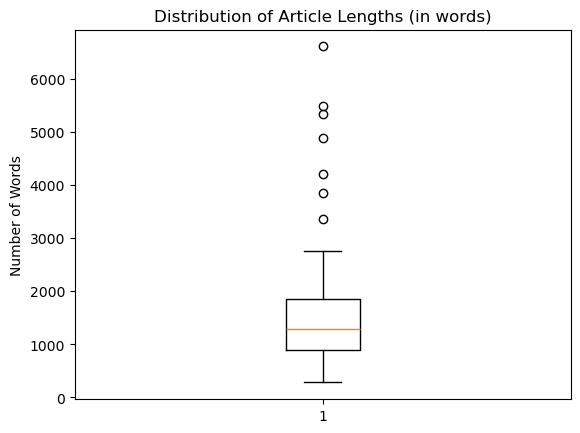

In [5]:
plt.boxplot(google_df['num_words'])
plt.title('Distribution of Article Lengths (in words)')
plt.ylabel('Number of Words')
plt.show()

In [6]:
hiv4 = ps.HIV4()
scores = []

for comment in google_df['text_body']:
    tokens = hiv4.tokenize(comment)
    score = hiv4.get_score(tokens)
    scores.append(score)

google_df['hiv4_pos_sentiment_count'] = [score['Positive'] for score in scores]
google_df['hiv4_neg_sentiment_count'] = [score['Negative'] for score in scores]
google_df.head()

,week,game_date,opponent,home_away,query,source,author,title,text_body,url,num_words,hiv4_pos_sentiment_count,hiv4_neg_sentiment_count
0,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35
1,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Yahoo Sports,NaN,"Cowboys vs. Eagles odds, predictions: Best bet...","Story by Matt Russell Contributing writer Thu,...",https://sports.yahoo.com/nfl/betting/article/c...,1439,102,61
2,2,9/14/25,Kansas City Chiefs,away,"Philadelphia Eagles at ""Kansas City Chiefs"" 20...",Philadelphia Eagles,NaN,"Game Recap: Eagles 20, Chiefs 17 | September 1...","Game Recap: Eagles 20, Chiefs 17 | September 1...",https://www.philadelphiaeagles.com/news/eagles...,1284,48,36
3,2,9/14/25,Kansas City Chiefs,away,"Philadelphia Eagles at ""Kansas City Chiefs"" 20...",Philadelphia Eagles,NaN,Spadaro: 10 observations from a dramatic win o...,Spadaro: 10 observations from a dramatic win o...,https://www.philadelphiaeagles.com/news/spadar...,1716,104,57
4,3,9/21/25,Los Angeles Rams,home,"Philadelphia Eagles vs ""Los Angeles Rams"" 2025...",Philadelphia Eagles,NaN,Los Angeles Rams at Philadelphia Eagles | Phil...,Los Angeles Rams at Philadelphia Eagles | Phil...,https://www.philadelphiaeagles.com/game-day/20...,1041,56,24


In [7]:
google_article_sentiment_by_week = google_df.groupby('week').agg({
    'hiv4_pos_sentiment_count': 'mean',
    'hiv4_neg_sentiment_count': 'mean'
}).reset_index()

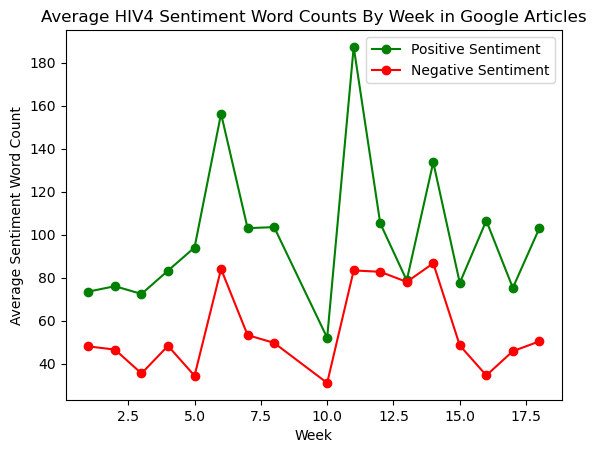

In [9]:
plt.plot(google_article_sentiment_by_week['week'], google_article_sentiment_by_week['hiv4_pos_sentiment_count'], marker='o', color='green', label='Positive Sentiment')
plt.plot(google_article_sentiment_by_week['week'], google_article_sentiment_by_week['hiv4_neg_sentiment_count'], marker='o', color='red', label='Negative Sentiment')
plt.xlabel('Week')
plt.ylabel('Average Sentiment Word Count')
plt.title('Average HIV4 Sentiment Word Counts By Week in Google Articles')
plt.legend()
plt.show()

## Sentence Level EDA

In [ ]:
import nltk
# nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/rjy2/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/rjy2/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [22]:
from nltk.tokenize import sent_tokenize
# nltk.data.path.append('/home/rjy2/nltk_data/tokenizers/punkt/')

sentences = []
for article in google_df['text_body']:
    article_sentences = sent_tokenize(article)
    sentences.append(article_sentences)
google_df['sentences'] = sentences
google_df.head()

,week,game_date,opponent,home_away,query,source,author,title,text_body,url,num_words,hiv4_pos_sentiment_count,hiv4_neg_sentiment_count,sentences
0,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"[Game Recap: Eagles 24, Cowboys 20 | September..."
1,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Yahoo Sports,NaN,"Cowboys vs. Eagles odds, predictions: Best bet...","Story by Matt Russell Contributing writer Thu,...",https://sports.yahoo.com/nfl/betting/article/c...,1439,102,61,[Story by Matt Russell Contributing writer Thu...
2,2,9/14/25,Kansas City Chiefs,away,"Philadelphia Eagles at ""Kansas City Chiefs"" 20...",Philadelphia Eagles,NaN,"Game Recap: Eagles 20, Chiefs 17 | September 1...","Game Recap: Eagles 20, Chiefs 17 | September 1...",https://www.philadelphiaeagles.com/news/eagles...,1284,48,36,"[Game Recap: Eagles 20, Chiefs 17 | September ..."
3,2,9/14/25,Kansas City Chiefs,away,"Philadelphia Eagles at ""Kansas City Chiefs"" 20...",Philadelphia Eagles,NaN,Spadaro: 10 observations from a dramatic win o...,Spadaro: 10 observations from a dramatic win o...,https://www.philadelphiaeagles.com/news/spadar...,1716,104,57,[Spadaro: 10 observations from a dramatic win ...
4,3,9/21/25,Los Angeles Rams,home,"Philadelphia Eagles vs ""Los Angeles Rams"" 2025...",Philadelphia Eagles,NaN,Los Angeles Rams at Philadelphia Eagles | Phil...,Los Angeles Rams at Philadelphia Eagles | Phil...,https://www.philadelphiaeagles.com/game-day/20...,1041,56,24,[Los Angeles Rams at Philadelphia Eagles | Phi...


In [23]:
google_sentence_df = google_df.explode('sentences').reset_index(drop=True)
google_sentence_df.head()

,week,game_date,opponent,home_away,query,source,author,title,text_body,url,num_words,hiv4_pos_sentiment_count,hiv4_neg_sentiment_count,sentences
0,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"Game Recap: Eagles 24, Cowboys 20 | September ..."
1,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"Sep 05, 2025 at 01:49 AM PhiladelphiaEagles.co..."
2,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"Game Highlights: Eagles 24, Cowboys 20 The Eag..."
3,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,Jalen Hurts scored two touchdowns and Philadel...
4,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,Here's how it happened: 1st Quarter Jalen Cart...


In [24]:
players = [
    'jalen', 'hurts', 'saquon', 'barkley', 'aj', 'a.j.', 'aj brown', 'a.j. brown', 'devonta', 'smith',
    'baun', 'quinyon', 'mitchell'    
]

google_sentence_df['contains_player_name'] = google_sentence_df['sentences'].str.contains('|'.join(players), case=False, na=False)
google_sentence_df.head()

,week,game_date,opponent,home_away,query,source,author,title,text_body,url,num_words,hiv4_pos_sentiment_count,hiv4_neg_sentiment_count,sentences,contains_player_name
0,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"Game Recap: Eagles 24, Cowboys 20 | September ...",False
1,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"Sep 05, 2025 at 01:49 AM PhiladelphiaEagles.co...",False
2,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,"Game Highlights: Eagles 24, Cowboys 20 The Eag...",False
3,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,Jalen Hurts scored two touchdowns and Philadel...,True
4,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,45,35,Here's how it happened: 1st Quarter Jalen Cart...,True


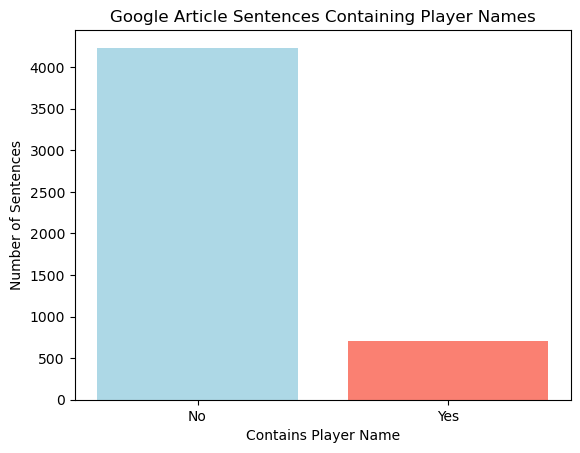

In [25]:
plt.bar(google_sentence_df['contains_player_name'].value_counts().index, google_sentence_df['contains_player_name'].value_counts().values, color=['lightblue', 'salmon'])
plt.xlabel('Contains Player Name')
plt.ylabel('Number of Sentences')
plt.title('Google Article Sentences Containing Player Names')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

Slightly more sentences contain player names than Reddit. Difference will likely grow bigger once we account for all player names

In [26]:
google_sentence_df.drop(columns=['hiv4_pos_sentiment_count', 'hiv4_neg_sentiment_count'], inplace=True)
scores = []

for sent in google_sentence_df['sentences']:
    tokens = hiv4.tokenize(sent)
    score = hiv4.get_score(tokens)
    scores.append(score)

google_sentence_df['hiv4_pos_sentiment_count'] = [score['Positive'] for score in scores]
google_sentence_df['hiv4_neg_sentiment_count'] = [score['Negative'] for score in scores]
google_sentence_df.head()

,week,game_date,opponent,home_away,query,source,author,title,text_body,url,num_words,sentences,contains_player_name,hiv4_pos_sentiment_count,hiv4_neg_sentiment_count
0,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,"Game Recap: Eagles 24, Cowboys 20 | September ...",False,2.0,0.0
1,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,"Sep 05, 2025 at 01:49 AM PhiladelphiaEagles.co...",False,0.0,0.0
2,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,"Game Highlights: Eagles 24, Cowboys 20 The Eag...",False,3.0,2.0
3,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,Jalen Hurts scored two touchdowns and Philadel...,True,0.0,0.0
4,1,9/4/25,Dallas Cowboys,home,"Philadelphia Eagles vs ""Dallas Cowboys"" 2025-0...",Philadelphia Eagles,NaN,"Game Recap: Eagles 24, Cowboys 20 | September ...","Game Recap: Eagles 24, Cowboys 20 | September ...",https://www.philadelphiaeagles.com/news/cowboy...,990,Here's how it happened: 1st Quarter Jalen Cart...,True,2.0,1.0


In [30]:
google_sent_by_player_mention = google_sentence_df.groupby(['week', 'contains_player_name']).agg({
    'hiv4_pos_sentiment_count': 'mean',
    'hiv4_neg_sentiment_count': 'mean'
}).reset_index()

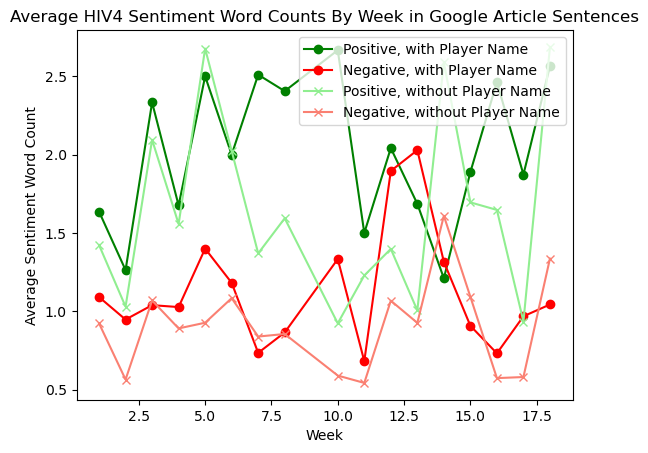

In [33]:
plt.plot(google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==True]['week'], google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==True]['hiv4_pos_sentiment_count'], marker='o', color='green', label='Positive, with Player Name')
plt.plot(google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==True]['week'], google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==True]['hiv4_neg_sentiment_count'], marker='o', color='red', label='Negative, with Player Name')
plt.plot(google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==False]['week'], google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==False]['hiv4_pos_sentiment_count'], marker='x', color='lightgreen', label='Positive, without Player Name')
plt.plot(google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==False]['week'], google_sent_by_player_mention[google_sent_by_player_mention['contains_player_name']==False]['hiv4_neg_sentiment_count'], marker='x', color='salmon', label='Negative, without Player Name')
plt.xlabel('Week')
plt.ylabel('Average Sentiment Word Count')
plt.title('Average HIV4 Sentiment Word Counts By Week in Google Article Sentences')
plt.legend()
plt.show()

Very roughly follows the entire article pattern

Almost always more positive sentiment words than negative sentiment words in a sentence, on average. Typically, sentences with a specific player mentioned have more sentiment words (both positive and negative)